In [1]:
# Import libraries

import pandas as pd
import numpy as np
import os

from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [2]:
# Dataset paths

dataset_path = "/user/HS402/nl00498/Downloads/melonoma_dataset"

train_csv_path = os.path.join(
    dataset_path,
    "train.csv"
)

train_images_path = os.path.join(
    dataset_path,
    "train"
)

In [3]:
# Load CSV file

df = pd.read_csv(train_csv_path)

# Show first rows
df.head()

,image_name,patient_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target,tfrecord,width,height
0,ISIC_2637011,IP_7279968,male,45.0,head/neck,unknown,benign,0,0,6000,4000
1,ISIC_0015719,IP_3075186,female,45.0,upper extremity,unknown,benign,0,0,6000,4000
2,ISIC_0052212,IP_2842074,female,50.0,lower extremity,nevus,benign,0,6,1872,1053
3,ISIC_0068279,IP_6890425,female,45.0,head/neck,unknown,benign,0,0,1872,1053
4,ISIC_0074268,IP_8723313,female,55.0,upper extremity,unknown,benign,0,11,6000,4000


In [4]:
# Check class distribution

print("Total samples:", len(df))

print(df["target"].value_counts())

Total samples: 33126
target
0    32542
1      584
Name: count, dtype: int64


In [5]:
# Function to preprocess images for Logistic Regression

def process_image(image_path):
    
    # Open image
    image = Image.open(image_path)
    
    # Convert to grayscale
    image = image.convert("L")
    
    # Resize image
    image = image.resize((64, 64))
    
    # Convert image to numpy array
    image_array = np.array(image)
    
    # Normalize pixel values to 0-1
    image_array = image_array / 255.0
    
    # Flatten image into 1D vector
    image_array = image_array.flatten()
    
    return image_array

In [6]:
# Create smaller stratified subset for Logistic Regression

df_small, _ = train_test_split(
    df,
    train_size=5000,
    stratify=df["target"],
    random_state=42
)

print("Subset size:", len(df_small))

print(df_small["target"].value_counts())

Subset size: 5000
target
0    4912
1      88
Name: count, dtype: int64


In [7]:
# Convert images into feature vectors

X = []
y = []

# Loop through dataset
for idx, row in df_small.iterrows():
    
    image_name = row["image_name"]
    label = row["target"]
    
    image_path = os.path.join(
        train_images_path,
        image_name + ".jpg"
    )
    
    # Process image
    features = process_image(image_path)
    
    # Store features and label
    X.append(features)
    y.append(label)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)

Feature matrix shape: (5000, 4096)
Labels shape: (5000,)


In [8]:
# Split data into train and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 4000
Validation samples: 1000


In [9]:
# Baseline Logistic Regression (without imbalance handling)

baseline_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_lr.fit(X_train, y_train)

print("Baseline Logistic Regression training complete.")

Baseline Logistic Regression training complete.


In [10]:
# Baseline predictions

baseline_preds = baseline_lr.predict(X_val)

# Baseline probabilities for ROC
baseline_probs = baseline_lr.predict_proba(X_val)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_val, baseline_preds))
print("Precision:", precision_score(y_val, baseline_preds))
print("Recall:", recall_score(y_val, baseline_preds))
print("F1 Score:", f1_score(y_val, baseline_preds))

# Confusion matrix
baseline_cm = confusion_matrix(y_val, baseline_preds)

print("Confusion Matrix:")
print(baseline_cm)

Accuracy: 0.981
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
[[981   1]
 [ 18   0]]


In [11]:
# Train Logistic Regression model

model_lr = LogisticRegression(
    class_weight='balanced',   # handle imbalance
    max_iter=1000,             # allow enough iterations
    random_state=42
)

# Train model
model_lr.fit(X_train, y_train)

print("Logistic Regression training complete.")

Logistic Regression training complete.


In [12]:
# Generate predictions on validation set

y_pred = model_lr.predict(X_val)

# Predict probabilities for ROC-AUC
y_probs = model_lr.predict_proba(X_val)[:, 1]

In [13]:
# Evaluate Logistic Regression model

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)

Accuracy: 0.944
Precision: 0.08695652173913043
Recall: 0.2222222222222222
F1 Score: 0.125
Confusion Matrix:
[[940  42]
 [ 14   4]]


In [17]:
# Apply custom threshold

custom_threshold = 0.3

# Convert probabilities into predictions
custom_preds = (y_probs > custom_threshold).astype(int)

# Evaluate threshold-tuned model
print("Accuracy:", accuracy_score(y_val, custom_preds))
print("Precision:", precision_score(y_val, custom_preds))
print("Recall:", recall_score(y_val, custom_preds))
print("F1 Score:", f1_score(y_val, custom_preds))

# Confusion matrix
custom_cm = confusion_matrix(y_val, custom_preds)

print("Confusion Matrix:")
print(custom_cm)

Accuracy: 0.887
Precision: 0.047619047619047616
Recall: 0.2777777777777778
F1 Score: 0.08130081300813008
Confusion Matrix:
[[882 100]
 [ 13   5]]


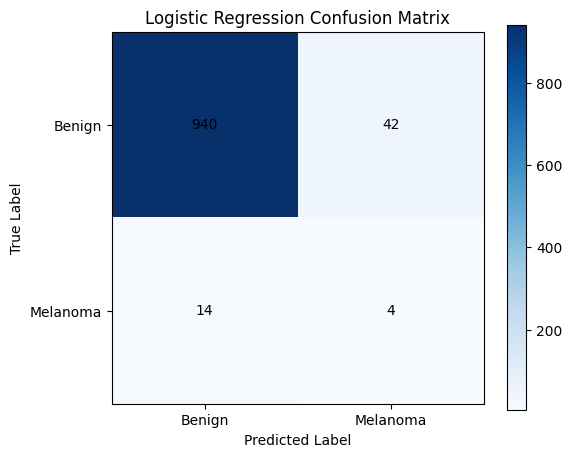

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

plt.imshow(cm, cmap='Blues')

# Labels
plt.xticks([0,1], ['Benign', 'Melanoma'])
plt.yticks([0,1], ['Benign', 'Melanoma'])

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Title
plt.title("Logistic Regression Confusion Matrix")

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar()

plt.show()

Baseline AUC: 0.654163837972392
Improved AUC: 0.6192577506223127


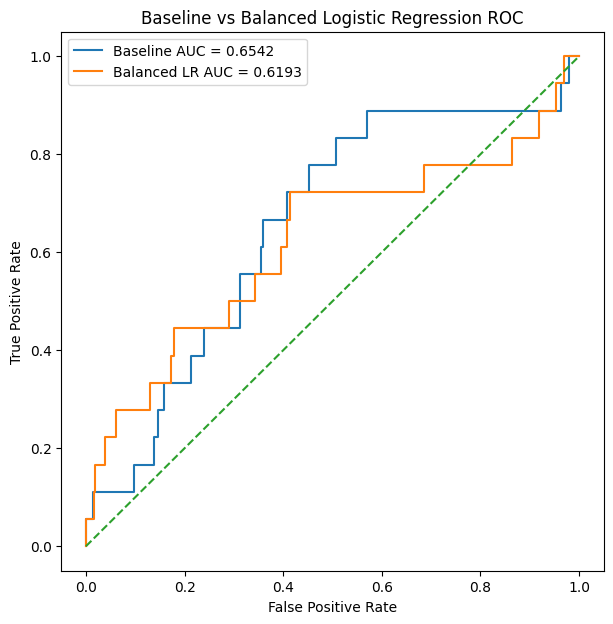

In [22]:
# Compute baseline ROC curve and AUC

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_val,
    baseline_probs
)

baseline_auc = auc(
    baseline_fpr,
    baseline_tpr
)

# Compute improved ROC curve and AUC

improved_fpr, improved_tpr, _ = roc_curve(
    y_val,
    y_probs
)

improved_auc = auc(
    improved_fpr,
    improved_tpr
)

print("Baseline AUC:", baseline_auc)
print("Improved AUC:", improved_auc)

# Plot ROC comparison

plt.figure(figsize=(7,7))

# Baseline ROC
plt.plot(
    baseline_fpr,
    baseline_tpr,
    label=f"Baseline AUC = {baseline_auc:.4f}"
)

# Balanced Logistic Regression ROC
plt.plot(
    improved_fpr,
    improved_tpr,
    label=f"Balanced LR AUC = {improved_auc:.4f}"
)

# Random baseline
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Baseline vs Balanced Logistic Regression ROC"
)

plt.legend()

plt.show()

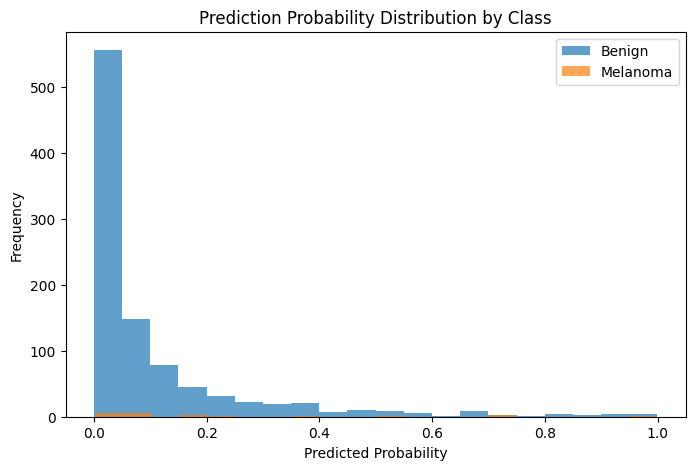

In [32]:
import matplotlib.pyplot as plt

# Separate probabilities by class
benign_probs = y_probs[y_val == 0]
melanoma_probs = y_probs[y_val == 1]

plt.figure(figsize=(8,5))

plt.hist(benign_probs, bins=20, alpha=0.7, label='Benign')
plt.hist(melanoma_probs, bins=20, alpha=0.7, label='Melanoma')

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")

plt.title("Prediction Probability Distribution by Class")

plt.legend()

plt.show()